In [1]:
#  Bước 2.0 — Nhập & Nạp dữ liệu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
APPROVED_COLOR = "#2ecc71"
REJECTED_COLOR = "#e74c3c"
NEUTRAL_COLOR  = "#3498db"

df = pd.read_csv("clean_loan_data.csv")

# Phần 1 mới: không có Total_Income, EMI — có thêm Property_Area
NUMERIC_COLS  = ["ApplicantIncome", "CoapplicantIncome",
                 "LoanAmount", "Loan_Amount_Term"]   # 4 biến liên tục
ORDINAL_COLS  = ["Credit_History", "Property_Area"]  # 2 biến rời rạc có thứ tự
TARGET_COL    = "Loan_Status"

print(f"Dữ liệu đầu vào : {df.shape[0]} dòng × {df.shape[1]} cột")
print(f"Các cột         : {df.columns.tolist()}")
print(f"Tỉ lệ Duyệt/TừChối : {df[TARGET_COL].value_counts().to_dict()}")
print(f"Property_Area phân bố: {df['Property_Area'].value_counts().sort_index().to_dict()}")
print(f"  (0=Rural, 1=Urban, 2=Semiurban)")
df.head()

Dữ liệu đầu vào : 614 dòng × 7 cột
Các cột         : ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']
Tỉ lệ Duyệt/TừChối : {1: 422, 0: 192}
Property_Area phân bố: {0: 179, 1: 202, 2: 233}
  (0=Rural, 1=Urban, 2=Semiurban)


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,5849,0.0,128.0,360.0,1.0,1,1
1,4583,1508.0,128.0,360.0,1.0,0,0
2,3000,0.0,66.0,360.0,1.0,1,1
3,2583,2358.0,120.0,360.0,1.0,1,1
4,6000,0.0,141.0,360.0,1.0,1,1


In [ ]:
# Bước 2.1 — Thống kê mô tả
pd.set_option("display.float_format", "{:.3f}".format)

all_cols = NUMERIC_COLS + ORDINAL_COLS
desc = df[all_cols].describe(percentiles=[.25, .5, .75, .95]).T
desc["skewness"] = df[all_cols].skew()
desc["kurtosis"] = df[all_cols].kurt()

print("=" * 70)
print("THỐNG KÊ MÔ TẢ")
print("=" * 70)
print(desc[["mean", "std", "min", "25%", "50%", "75%", "95%", "max",
            "skewness", "kurtosis"]])

print("\n" + "=" * 70)
print("⚠  PHÂN TÍCH TỰ ĐỘNG — CÁC CỘT CẦN LƯU Ý")
print("=" * 70)

# Thu thập kết quả động
cols_can_xem_xet = []   # cần xem xét cách lọc outlier ở Bước 2.2
cols_du_kien_mw  = []   # dự kiến Mann-Whitney — Bước 2.3 xác nhận
cols_du_kien_tt  = []   # dự kiến T-test — Bước 2.3 xác nhận

for col in NUMERIC_COLS:
    skew = df[col].skew()
    kurt = df[col].kurt()
    flags = []

    if abs(skew) > 3:
        flags.append(f"lệch {'phải' if skew > 0 else 'trái'} NẶNG (skew={skew:.2f})")
    elif abs(skew) > 1:
        flags.append(f"lệch {'phải' if skew > 0 else 'trái'} vừa (skew={skew:.2f})")
    else:
        flags.append(f"gần chuẩn (skew={skew:.2f})")

    if kurt > 10:
        flags.append(f"đuôi rất nặng (kurt={kurt:.1f}) → nhiều outlier")

    if abs(skew) > 1:
        flags.append("→ lệch nặng, cần xem xét cách lọc outlier ở Bước 2.2")
        cols_du_kien_mw.append(col)
        cols_can_xem_xet.append(col)
    else:
        flags.append("→ gần chuẩn, Bước 2.2 sẽ xem xét")
        cols_du_kien_tt.append(col)
        cols_can_xem_xet.append(col)

    status = "🔴" if abs(skew) > 3 else ("🟡" if abs(skew) > 1 else "🟢")
    print(f"  {status} {col:<22}: {' | '.join(flags)}")

print()

# Biến rời rạc — chỉ ghi nhận, không xử lý ở bước này
cols_chisq = []
for col in ORDINAL_COLS:
    cols_chisq.append(col)
    print(f"  ℹ️  {col:<22}: biến rời rạc — không đưa vào lọc outlier, Bước 2.3 xử lý riêng")

# Tóm tắt
print()
print("─" * 70)
print("📌 NHẬN XÉT & HƯỚNG XỬ LÝ DỰ KIẾN")
print("─" * 70)
print(f"  Cần xem xét cách lọc outlier : {cols_can_xem_xet}")
print(f"  Lý do                         : skewness > 1 → lệch nặng")
print(f"                                  → Bước 2.2 sẽ quyết định phương pháp lọc")
print()
print(f"  Không đưa vào lọc outlier     : {ORDINAL_COLS}  (biến rời rạc)")
print()
print("  Dự kiến kiểm định (Bước 2.3 xác nhận bằng Shapiro-Wilk):")
if cols_du_kien_mw:
    print(f"  → Dự kiến Mann-Whitney        : {cols_du_kien_mw}")
if cols_du_kien_tt:
    print(f"  → Dự kiến T-test              : {cols_du_kien_tt}")
if cols_chisq:
    print(f"  → Dự kiến Chi-square          : {cols_chisq}")

THỐNG KÊ MÔ TẢ
                      mean      std     min      25%      50%      75%  \
ApplicantIncome   5403.459 6109.042 150.000 2877.500 3812.500 5795.000   
CoapplicantIncome 1621.246 2926.248   0.000    0.000 1188.500 2297.250   
LoanAmount         145.752   84.107   9.000  100.250  128.000  164.750   
Loan_Amount_Term   342.410   64.429  12.000  360.000  360.000  360.000   
Credit_History       0.855    0.352   0.000    1.000    1.000    1.000   
Property_Area        1.088    0.815   0.000    0.000    1.000    2.000   

                        95%       max  skewness  kurtosis  
ApplicantIncome   14583.000 81000.000     6.540    60.541  
CoapplicantIncome  4997.400 41667.000     7.492    84.956  
LoanAmount          293.400   700.000     2.743    10.937  
Loan_Amount_Term    360.000   480.000    -2.402     6.925  
Credit_History        1.000     1.000    -2.022     2.095  
Property_Area         2.000     2.000    -0.163    -1.477  

⚠  PHÂN TÍCH TỰ ĐỘNG — CÁC CỘT CẦN LƯU Ý
  🔴 

NHÓM 1 — Biến liên tục: Lọc bằng IQR × 3.0
─────────────────────────────────────────────────────────────────
  ApplicantIncome       : [-5875.0 ; 14547.5]  →  32 outliers (5.2%)
  CoapplicantIncome     : [-6891.8 ; 9189.0]  →  6 outliers (1.0%)
  LoanAmount            : [-93.2 ; 358.2]  →  19 outliers (3.1%)

NHÓM 2 — Biến rời rạc: Kiểm tra giá trị hợp lệ (không dùng IQR)
─────────────────────────────────────────────────────────────────
  Loan_Amount_Term — Phân bố:
Loan_Amount_Term
12.000       1
36.000       2
60.000       2
84.000       4
120.000      3
180.000     44
240.000      4
300.000     13
360.000    526
480.000     15
  Dòng không hợp lệ: 0
  ✅ Tất cả kỳ hạn hợp lệ — KHÔNG xóa dòng nào

  Property_Area — Phân bố:
Property_Area
Rural        179
Urban        202
Semiurban    233
  Dòng không hợp lệ: 0
  ✅ Tất cả khu vực hợp lệ — KHÔNG xóa dòng nào

  Credit_History — Phân bố: {1.0: 525, 0.0: 89}
  ✅ Biến nhị phân — KHÔNG lọc outlier

──────────────────────────────────────────

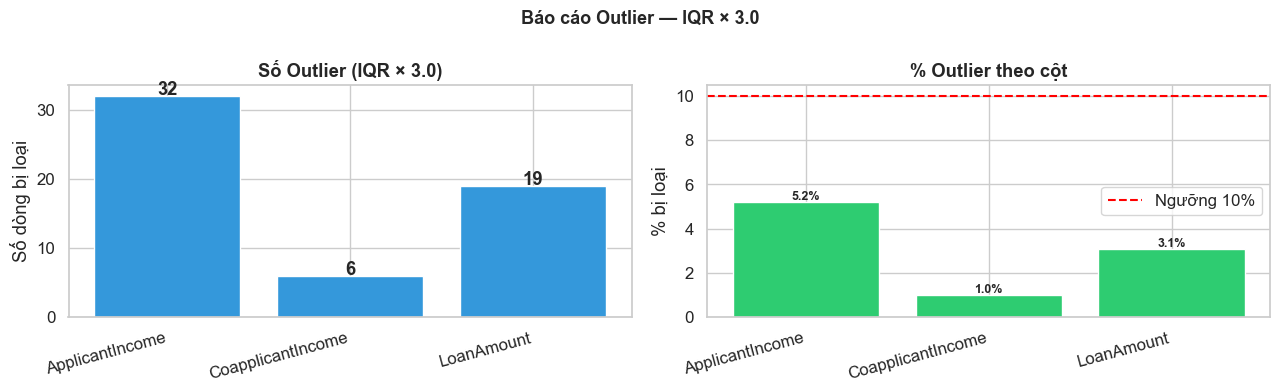

In [3]:
# Bước 2.2 — Lọc ngoại lệ (IQR × 3.0 + Kiểm tra nghiệp vụ)
IQR_MULTIPLIER = 3.0

outlier_report = {}
bounds         = {}
mask_keep      = pd.Series(True, index=df.index)

# ── NHÓM 1: Biến liên tục → IQR ────────────────────────────
print(f"NHÓM 1 — Biến liên tục: Lọc bằng IQR × {IQR_MULTIPLIER}")
print("─" * 65)

CONTINUOUS_COLS = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]
# Loan_Amount_Term xử lý riêng như nhóm 2

for col in CONTINUOUS_COLS:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - IQR_MULTIPLIER * IQR
    upper = Q3 + IQR_MULTIPLIER * IQR
    is_out = (df[col] < lower) | (df[col] > upper)
    outlier_report[col] = is_out.sum()
    bounds[col]         = (lower, upper)
    mask_keep          &= ~is_out
    print(f"  {col:<22}: [{lower:.1f} ; {upper:.1f}]  →  {is_out.sum()} outliers ({is_out.mean()*100:.1f}%)")

# ── NHÓM 2: Biến rời rạc nghiệp vụ → Kiểm tra tập giá trị ─
print("\nNHÓM 2 — Biến rời rạc: Kiểm tra giá trị hợp lệ (không dùng IQR)")
print("─" * 65)

# Loan_Amount_Term
VALID_TERMS = {12, 36, 60, 84, 120, 180, 240, 300, 360, 480}
invalid_term = ~df["Loan_Amount_Term"].isin(VALID_TERMS)
print(f"  Loan_Amount_Term — Phân bố:\n{df['Loan_Amount_Term'].value_counts().sort_index().to_string()}")
print(f"  Dòng không hợp lệ: {invalid_term.sum()}")
if invalid_term.sum() > 0:
    mask_keep &= ~invalid_term
    print(f"  → Xóa {invalid_term.sum()} dòng")
else:
    print("  ✅ Tất cả kỳ hạn hợp lệ — KHÔNG xóa dòng nào")

# Property_Area
VALID_AREAS = {0, 1, 2}   # Rural=0, Urban=1, Semiurban=2
invalid_area = ~df["Property_Area"].isin(VALID_AREAS)
print(f"\n  Property_Area — Phân bố:\n{df['Property_Area'].value_counts().sort_index().rename({0:'Rural',1:'Urban',2:'Semiurban'}).to_string()}")
print(f"  Dòng không hợp lệ: {invalid_area.sum()}")
if invalid_area.sum() > 0:
    mask_keep &= ~invalid_area
else:
    print("  ✅ Tất cả khu vực hợp lệ — KHÔNG xóa dòng nào")

# Credit_History
invalid_credit = ~df["Credit_History"].isin([0.0, 1.0])
print(f"\n  Credit_History — Phân bố: {df['Credit_History'].value_counts().to_dict()}")
print(f"  ✅ Biến nhị phân — KHÔNG lọc outlier")

# Tổng kết
n_before  = len(df)
df_clean  = df[mask_keep].copy().reset_index(drop=True)
n_after   = len(df_clean)
approved  = df_clean[df_clean[TARGET_COL] == 1]
rejected  = df_clean[df_clean[TARGET_COL] == 0]

print(f"\n{'─'*65}")
print(f"  Trước lọc : {n_before} dòng")
print(f"  Sau lọc   : {n_after}  dòng  (giữ {n_after/n_before*100:.1f}%)")
pct = (n_before - n_after) / n_before * 100
print(f"  {'✅ Hợp lý' if pct < 10 else '⚠️  Hơi nhiều, cân nhắc tăng hệ số'} — loại {pct:.1f}%")

# Biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
bars = axes[0].bar(outlier_report.keys(), outlier_report.values(),
                   color=NEUTRAL_COLOR, edgecolor="white")
for bar, val in zip(bars, outlier_report.values()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 str(val), ha='center', fontweight='bold')
axes[0].set_title(f"Số Outlier (IQR × {IQR_MULTIPLIER})", fontweight='bold')
axes[0].set_ylabel("Số dòng bị loại")
axes[0].set_xticklabels(outlier_report.keys(), rotation=15, ha='right')

pct_vals = [v/n_before*100 for v in outlier_report.values()]
colors   = [REJECTED_COLOR if p > 10 else APPROVED_COLOR for p in pct_vals]
axes[1].bar(outlier_report.keys(), pct_vals, color=colors, edgecolor="white")
axes[1].axhline(10, color='red', linestyle='--', linewidth=1.5, label='Ngưỡng 10%')
for bar, val in zip(axes[1].patches, pct_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f"{val:.1f}%", ha='center', fontweight='bold', fontsize=9)
axes[1].set_title("% Outlier theo cột", fontweight='bold')
axes[1].set_ylabel("% bị loại")
axes[1].set_xticklabels(outlier_report.keys(), rotation=15, ha='right')
axes[1].legend()

plt.suptitle(f"Báo cáo Outlier — IQR × {IQR_MULTIPLIER}", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

KIỂM ĐỊNH THỐNG KÊ — Biến liên tục vs Loan_Status
Quy tắc: Shapiro-Wilk p < 0.05 → không chuẩn → Mann-Whitney

  ApplicantIncome
    Dùng   : Mann-Whitney  (không chuẩn (p_shapiro: 0.000, 0.000))
    p-value: 0.63148  →  ✘ Không ý nghĩa

  CoapplicantIncome
    Dùng   : Mann-Whitney  (không chuẩn (p_shapiro: 0.000, 0.000))
    p-value: 0.11075  →  ✘ Không ý nghĩa

  LoanAmount
    Dùng   : Mann-Whitney  (không chuẩn (p_shapiro: 0.000, 0.000))
    p-value: 0.73811  →  ✘ Không ý nghĩa

  Loan_Amount_Term
    Dùng   : Mann-Whitney  (không chuẩn (p_shapiro: 0.000, 0.000))
    p-value: 0.58577  →  ✘ Không ý nghĩa

CHI-SQUARE — Credit_History vs Loan_Status
  χ² = 169.8948  |  p = 7.80e-39  |  dof = 1
  → ✔ CÓ ý nghĩa — Credit_History quyết định mạnh nhất!

CHI-SQUARE — Property_Area vs Loan_Status
  Bảng chéo (0=Rural, 1=Urban, 2=Semiurban):
Loan_Status     0    1
Property_Area         
0              63  103
1              64  125
2              50  166

  χ² = 10.7005  |  p = 0.0047  |  d

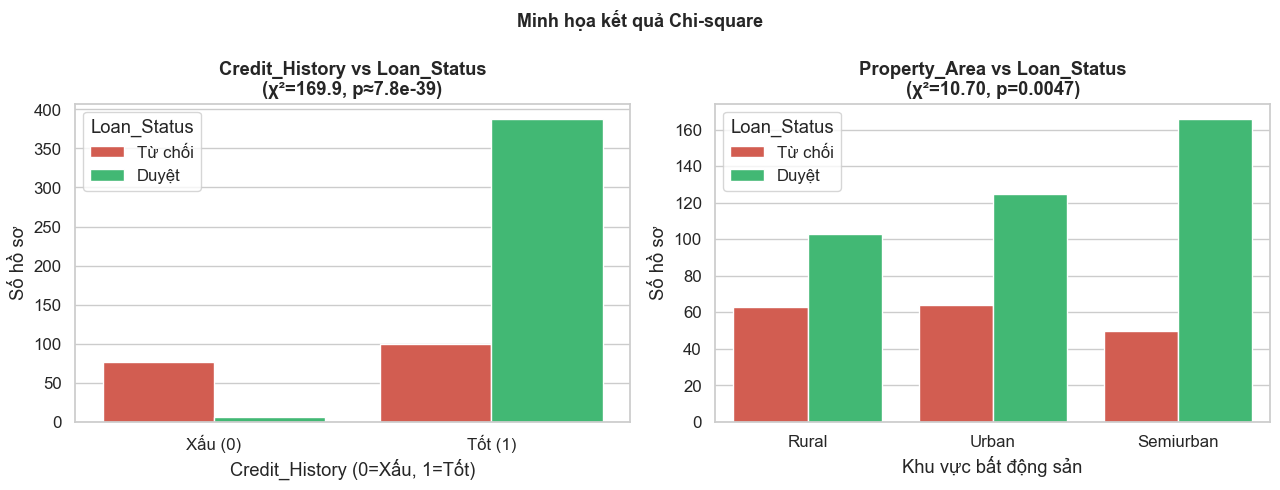

In [4]:
# Bước 2.3 — Kiểm định thống kê
ALPHA        = 0.05
test_results = []

print("=" * 70)
print("KIỂM ĐỊNH THỐNG KÊ — Biến liên tục vs Loan_Status")
print("Quy tắc: Shapiro-Wilk p < 0.05 → không chuẩn → Mann-Whitney")
print("=" * 70)

for col in NUMERIC_COLS:
    a_vals = approved[col].dropna()
    r_vals = rejected[col].dropna()
    _, p_a    = stats.shapiro(a_vals)
    _, p_r    = stats.shapiro(r_vals)
    is_normal = (p_a > 0.05) and (p_r > 0.05)

    if is_normal:
        stat, p_val = stats.ttest_ind(a_vals, r_vals)
        test_name   = "T-test      "
        reason      = f"chuẩn (p_shapiro: {p_a:.3f}, {p_r:.3f})"
    else:
        stat, p_val = stats.mannwhitneyu(a_vals, r_vals, alternative='two-sided')
        test_name   = "Mann-Whitney"
        reason      = f"không chuẩn (p_shapiro: {p_a:.3f}, {p_r:.3f})"

    sig = "✔ Có ý nghĩa" if p_val < ALPHA else "✘ Không ý nghĩa"
    test_results.append({"Cột": col, "Kiểm định": test_name.strip(),
                         "p-value": round(p_val, 5), "Kết quả": sig})
    print(f"\n  {col}")
    print(f"    Dùng   : {test_name}  ({reason})")
    print(f"    p-value: {p_val:.5f}  →  {sig}")

df_test = pd.DataFrame(test_results)

# Chi-square cho Credit_History
print("\n" + "=" * 70)
print("CHI-SQUARE — Credit_History vs Loan_Status")
ct_cr = pd.crosstab(df_clean["Credit_History"], df_clean[TARGET_COL])
chi2_cr, p_cr, dof_cr, _ = stats.chi2_contingency(ct_cr)
print(f"  χ² = {chi2_cr:.4f}  |  p = {p_cr:.2e}  |  dof = {dof_cr}")
print(f"  → {'✔ CÓ ý nghĩa — Credit_History quyết định mạnh nhất!' if p_cr < ALPHA else '✘'}")

# Chi-square cho Property_Area
print("\n" + "=" * 70)
print("CHI-SQUARE — Property_Area vs Loan_Status")
ct_pa = pd.crosstab(df_clean["Property_Area"], df_clean[TARGET_COL])
print(f"  Bảng chéo (0=Rural, 1=Urban, 2=Semiurban):\n{ct_pa}")
chi2_pa, p_pa, dof_pa, _ = stats.chi2_contingency(ct_pa)
print(f"\n  χ² = {chi2_pa:.4f}  |  p = {p_pa:.4f}  |  dof = {dof_pa}")
print(f"  → {'✔ CÓ ý nghĩa — Khu vực ảnh hưởng đến phê duyệt' if p_pa < ALPHA else '✘ Không ý nghĩa'}")

# Kết luận tổng hợp
print("\n" + "─" * 70)
print("📌 KẾT LUẬN — Dùng cho Phần 3 & 4:")
sig_cols = [r["Cột"] for _, r in df_test.iterrows() if "Có" in r["Kết quả"]]
no_cols  = [r["Cột"] for _, r in df_test.iterrows() if "Không" in r["Kết quả"]]
if sig_cols: print(f"  Phân biệt được 2 nhóm: {sig_cols}")
if no_cols:  print(f"  Không phân biệt riêng lẻ: {no_cols}")
print(f"  → KNN cần kết hợp nhiều chiều mới hiệu quả")
print(f"  Credit_History (χ²={chi2_cr:.1f}, p≈0) → KHÔNG được bỏ khỏi model")
print(f"  Property_Area (χ²={chi2_pa:.2f}, p={p_pa:.4f}) → {'Giữ lại' if p_pa < ALPHA else 'Cân nhắc bỏ'}")

# ── Minh họa trực quan kết quả Chi-square ──────────────────
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Credit_History
sns.countplot(data=df_clean, x='Credit_History',
              hue=TARGET_COL,
              palette={0: REJECTED_COLOR, 1: APPROVED_COLOR},
              ax=axes[0])
axes[0].set_title(f"Credit_History vs Loan_Status\n(χ²={chi2_cr:.1f}, p≈{p_cr:.1e})",
                  fontweight='bold')
axes[0].set_xlabel("Credit_History (0=Xấu, 1=Tốt)")
axes[0].set_ylabel("Số hồ sơ")
axes[0].set_xticklabels(['Xấu (0)', 'Tốt (1)'])
axes[0].legend(title='Loan_Status', labels=['Từ chối', 'Duyệt'])

# Property_Area
df_plot = df_clean.copy()
df_plot['Property_Area_Label'] = df_plot['Property_Area'].map(
    {0: 'Rural', 1: 'Urban', 2: 'Semiurban'})
sns.countplot(data=df_plot, x='Property_Area_Label',
              hue=TARGET_COL,
              palette={0: REJECTED_COLOR, 1: APPROVED_COLOR},
              order=['Rural', 'Urban', 'Semiurban'],
              ax=axes[1])
axes[1].set_title(f"Property_Area vs Loan_Status\n(χ²={chi2_pa:.2f}, p={p_pa:.4f})",
                  fontweight='bold')
axes[1].set_xlabel("Khu vực bất động sản")
axes[1].set_ylabel("Số hồ sơ")
axes[1].legend(title='Loan_Status', labels=['Từ chối', 'Duyệt'])

plt.suptitle("Minh họa kết quả Chi-square",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

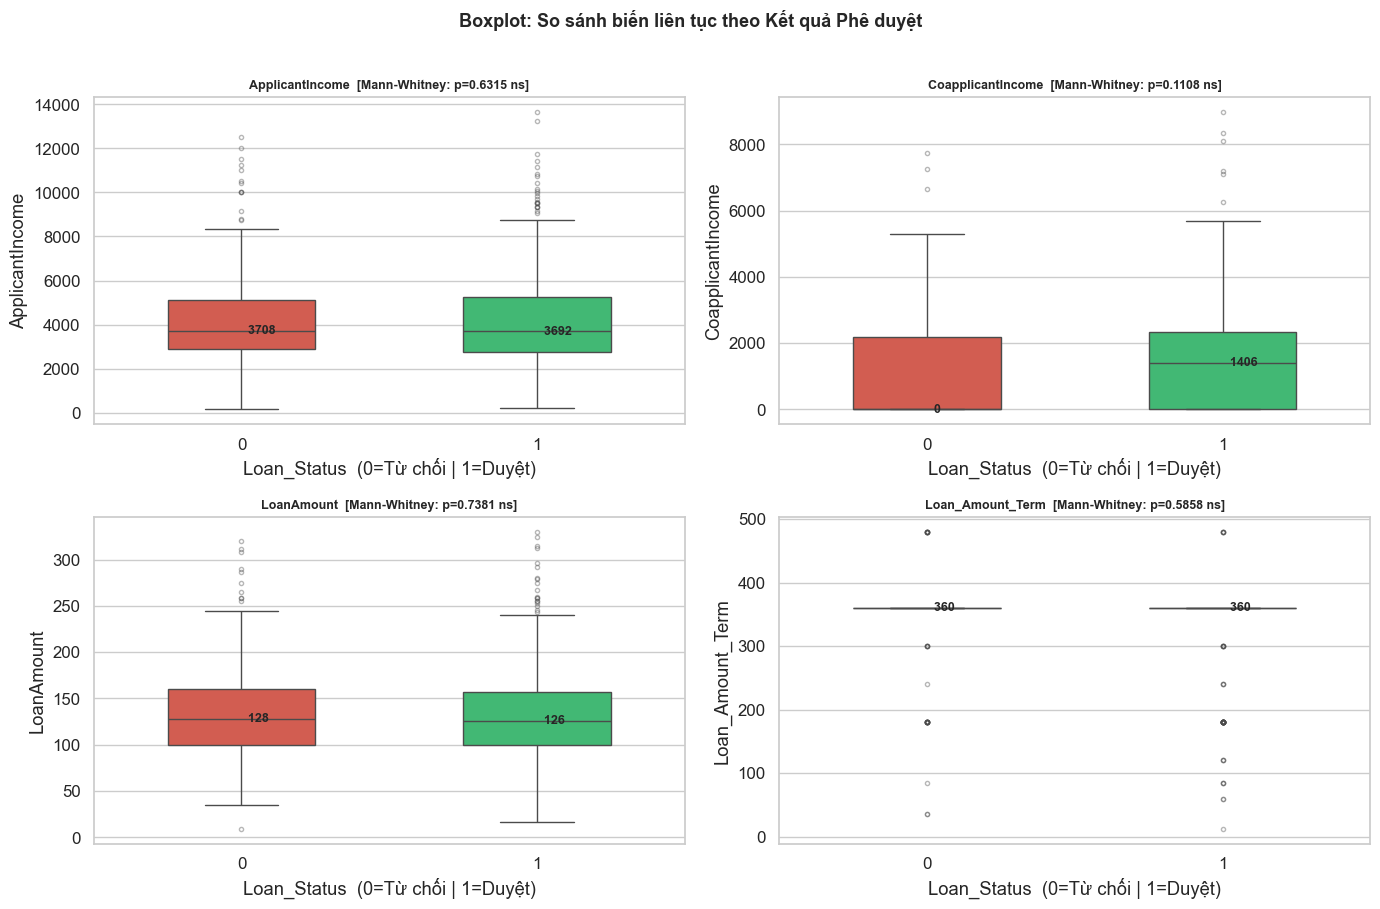

📌 KẾT LUẬN Boxplot:
  Tất cả 'ns' → median 2 nhóm gần nhau → KNN cần kết hợp nhiều feature


In [5]:
# Bước 2.4 — Boxplot
plt.close('all')
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    ax = axes[i]
    sns.boxplot(data=df_clean, x=TARGET_COL, y=col,
                hue=TARGET_COL,
                palette={0: REJECTED_COLOR, 1: APPROVED_COLOR},
                width=0.5, legend=False,
                flierprops=dict(marker='o', markersize=3, alpha=0.4),
                ax=ax)
    ax.set_xlabel("Loan_Status  (0=Từ chối | 1=Duyệt)")

    for x_val, grp in df_clean.groupby(TARGET_COL):
        median = grp[col].median()
        ax.text(x_val, median, f"  {median:.0f}",
                va='center', fontsize=9, fontweight='bold')

    p_row = df_test[df_test["Cột"] == col]
    if not p_row.empty:
        p_val  = p_row["p-value"].values[0]
        t_name = p_row["Kiểm định"].values[0]
        mark   = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "ns"))
        ax.set_title(f"{col}  [{t_name}: p={p_val:.4f} {mark}]",
                     fontweight='bold', fontsize=9)

plt.suptitle("Boxplot: So sánh biến liên tục theo Kết quả Phê duyệt",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("📌 KẾT LUẬN Boxplot:")
print("  Tất cả 'ns' → median 2 nhóm gần nhau → KNN cần kết hợp nhiều feature")

In [6]:
# Bước 2.5 — Lưu file 
df_clean.to_csv("clean_no_outlier.csv", index=False)
print(f"✔ clean_no_outlier.csv — {df_clean.shape}")
print(f"  Dùng cho Phần 3 (KNN tự code) và Phần 4 (sklearn)")
print(f"  Mất cân bằng: Duyệt={int(df_clean[TARGET_COL].sum())} | Từ chối={int((df_clean[TARGET_COL]==0).sum())}")

✔ clean_no_outlier.csv — (571, 7)
  Dùng cho Phần 3 (KNN tự code) và Phần 4 (sklearn)
  Mất cân bằng: Duyệt=394 | Từ chối=177
